# Week 4 Day 1 — Yield-Change Panel

Turns the daily Svensson fits into the matrix PCA needs.

**Two key design choices:**

1. **Evaluate at fixed maturities, not bond maturities.** The Svensson model gives us
   a continuous curve. We sample it at `[0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]` years —
   the standard benchmark tenors — so we get a consistent 10-column matrix every day.

2. **First-difference before PCA.** Yield *levels* trend across decades (non-stationary).
   Daily yield *changes* are approximately stationary — they look like noise around zero
   in any era. PCA applied to levels would just find "rates were high in 1980" as a
   principal component, which is useless for trading.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from termstructure.pca.panel import build_zero_panel, DEFAULT_MATURITIES

## 1. Build the panel

Evaluates the Svensson curve at 10 maturities for every date in
`svensson_params.parquet`, then first-differences.

In [2]:
panel = build_zero_panel()
print(f'Shape: {panel.shape}')
print(f'Date range: {panel.date.min().date()} → {panel.date.max().date()}')
panel.head()

Shape: (10094, 17)
Date range: 1985-11-25 → 2026-05-01


,date,y_1,dy_1,y_2,dy_2,y_3,dy_3,y_5,dy_5,y_7,dy_7,y_10,dy_10,y_20,dy_20,y_30,dy_30
0,1985-11-25,0.078551,NaN,0.083626,NaN,0.087469,NaN,0.092686,NaN,0.095924,NaN,0.098969,NaN,0.104428,NaN,0.107618,NaN
1,1985-11-26,0.078527,-0.24,0.083575,-0.51,0.087420,-0.49,0.092677,-0.09,0.095956,0.32,0.099015,0.46,0.104150,-2.78,0.106917,-7.01
2,1985-11-27,0.078425,-1.02,0.083522,-0.53,0.087339,-0.81,0.092453,-2.24,0.095586,-3.70,0.098515,-5.00,0.103781,-3.69,0.106796,-1.21
3,1985-11-29,0.077914,-5.11,0.083148,-3.74,0.086991,-3.48,0.092024,-4.29,0.095061,-5.25,0.097938,-5.77,0.103403,-3.78,0.106528,-2.68
4,1985-12-02,0.078176,2.62,0.083457,3.09,0.087359,3.68,0.092550,5.26,0.095766,7.05,0.098874,9.36,0.104483,10.80,0.107335,8.07


## 2. Spot-check levels

Plot the 2Y, 10Y, and 30Y zero rates over time. These should match what we
saw in notebook 14 — the validation already confirmed our fits track the Fed.

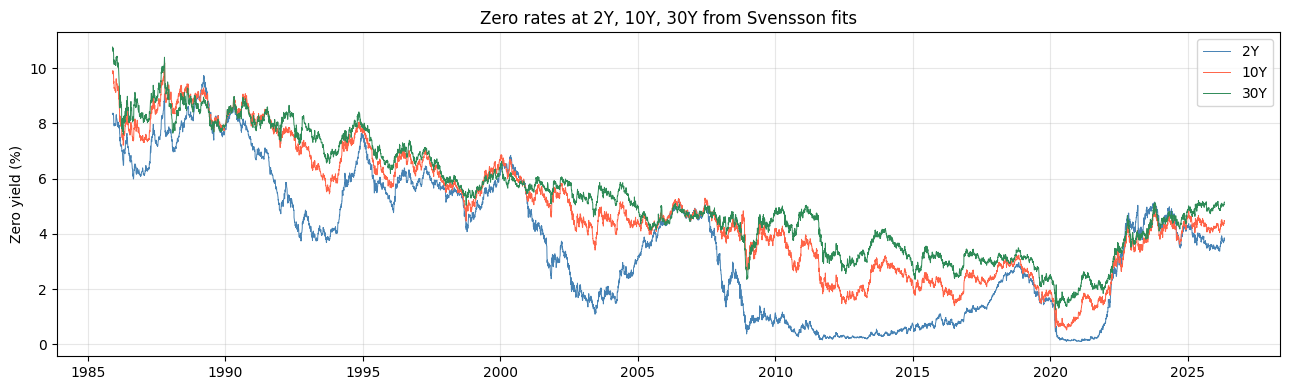

In [3]:
p = panel.set_index('date')

fig, ax = plt.subplots(figsize=(13, 4))
for mat, color in [(2, 'steelblue'), (10, 'tomato'), (30, 'seagreen')]:
    label = str(mat)
    ax.plot(p.index, p[f'y_{label}'] * 100, lw=0.7, label=f'{mat}Y', color=color)
ax.set_ylabel('Zero yield (%)')
ax.set_title('Zero rates at 2Y, 10Y, 30Y from Svensson fits')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Snapshot curves at key dates

Three historical regimes illustrate the shape variety PCA must explain:
- **1981-09-30**: peak Volcker — inverted curve, rates > 15%
- **2006-06-30**: pre-GFC flat curve
- **2021-01-04**: post-COVID steep curve, long end elevated

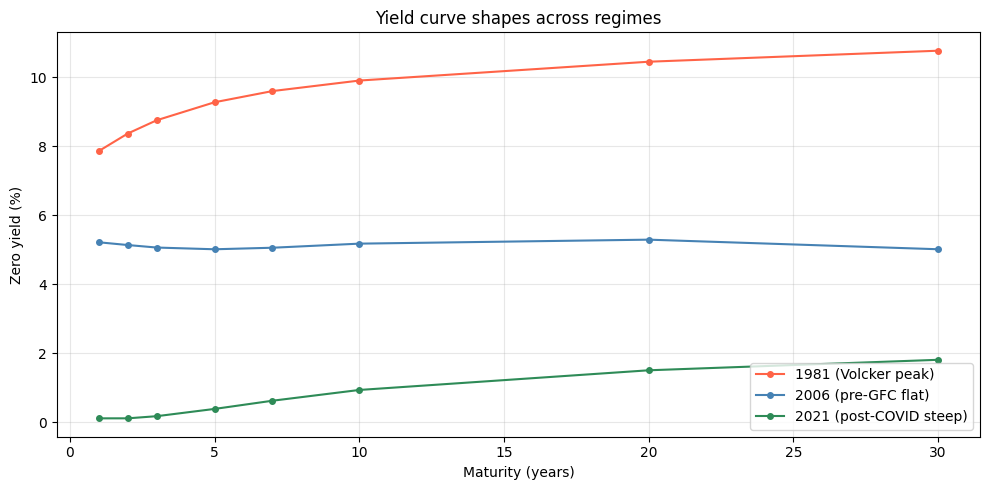

In [4]:
level_cols = [f'y_{str(int(m)) if m == int(m) else str(m)}' for m in DEFAULT_MATURITIES]
p = panel.set_index('date')

dates = ['1981-09-30', '2006-06-30', '2021-01-04']
labels = ['1981 (Volcker peak)', '2006 (pre-GFC flat)', '2021 (post-COVID steep)']
colors = ['tomato', 'steelblue', 'seagreen']

fig, ax = plt.subplots(figsize=(10, 5))
for date, label, color in zip(dates, labels, colors):
    # find nearest available date
    idx = p.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    row = p.iloc[idx][level_cols].values * 100
    ax.plot(DEFAULT_MATURITIES, row, marker='o', ms=4, lw=1.5, label=label, color=color)

ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Zero yield (%)')
ax.set_title('Yield curve shapes across regimes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Inspect the daily changes

The `dy_` columns are the PCA input. Summary statistics to check:
- Mean ≈ 0 at all maturities (changes are unbiased noise)
- Short-end more volatile than long-end in normal periods
- Large spikes correspond to macro shocks (2008, 2020, 2022)

In [5]:
change_cols = [f'dy_{str(int(m)) if m == int(m) else str(m)}' for m in DEFAULT_MATURITIES]
changes = panel[change_cols].iloc[1:]  # drop first NaN row

summary = pd.DataFrame({
    'maturity': DEFAULT_MATURITIES,
    'mean_bp':  changes.mean().values.round(3),
    'std_bp':   changes.std().values.round(3),
    'p5_bp':    changes.quantile(0.05).values.round(2),
    'p95_bp':   changes.quantile(0.95).values.round(2),
}).set_index('maturity')
summary

,mean_bp,std_bp,p5_bp,p95_bp
maturity,,,,
1,-0.040,4.522,-6.79,6.46
2,-0.045,5.489,-8.47,8.37
3,-0.048,5.903,-9.20,9.19
5,-0.052,6.114,-9.42,9.88
7,-0.053,6.116,-9.42,9.97
10,-0.054,6.043,-9.31,9.81
20,-0.053,5.663,-8.85,9.13
30,-0.056,5.955,-9.16,9.25


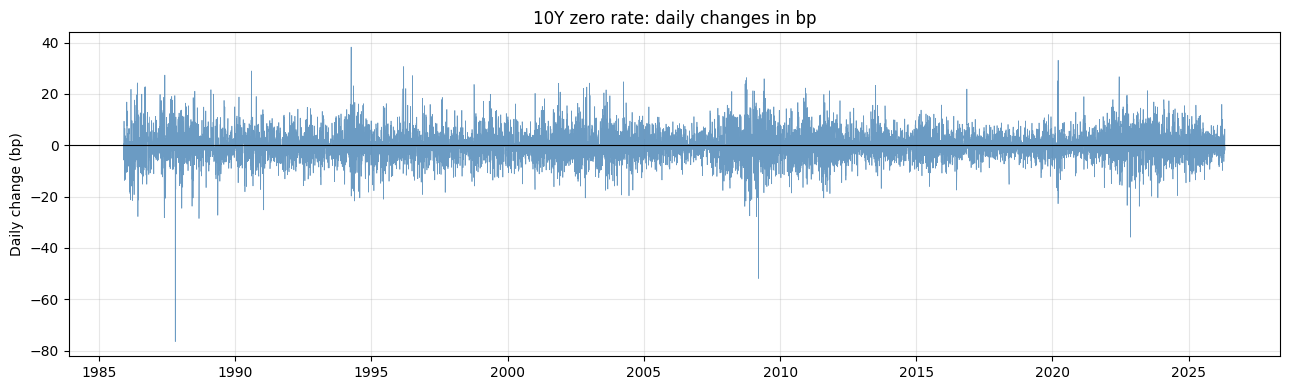

In [6]:
p = panel.set_index('date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(p.index[1:], p['dy_10'].iloc[1:], lw=0.5, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Daily change (bp)')
ax.set_title('10Y zero rate: daily changes in bp')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Volatility by maturity

Standard deviation of daily changes (bp) at each tenor.
This is the term structure of vol — should be roughly hump-shaped,
with the 2Y–5Y range most volatile (driven by Fed expectations).

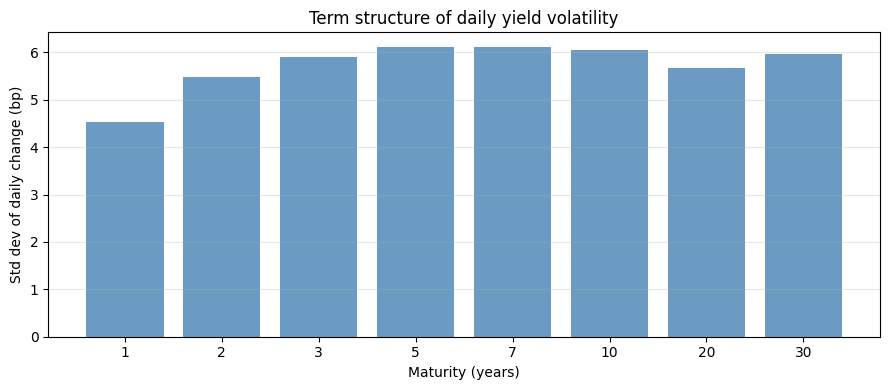

In [7]:
vols = changes.std()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(DEFAULT_MATURITIES)), vols.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(DEFAULT_MATURITIES)))
ax.set_xticklabels([str(m) for m in DEFAULT_MATURITIES])
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Std dev of daily change (bp)')
ax.set_title('Term structure of daily yield volatility')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()